### Lineare Regression mit Keras nachbauen

#### 1) Daten laden

In [23]:
import pandas as pd
from math import ceil

pd.set_option('display.max_columns', 6)

data_url=r'https://raw.githubusercontent.com/rawe64/ai/main/ndx100.csv'
df = pd.read_csv(data_url)
df.head()

,m199,m99,m49,...,m3,m1,p5
0,-34.023668,-24.908597,-26.302555,...,-3.567182,0.328812,-5.638866
1,-45.493319,-34.786439,-31.315602,...,-10.180812,-5.099538,-6.134486
2,-42.415836,-36.541864,-34.279911,...,-4.975005,-0.211015,-6.591711
3,-53.283988,-36.786283,-40.070083,...,-9.990068,-4.432868,-6.060527
4,-40.239003,-34.040967,-29.901523,...,1.331406,5.718546,-9.906045


#### 2) x-/y-Daten selektieren und standardisieren

In [24]:
from sklearn.preprocessing import StandardScaler

X = df[['m199', 'm99','m49','m19','m9','m5','m3','m1']].values
y = df[['p5']].values

scaler_X = StandardScaler()
X = scaler_X.fit_transform(X)

scaler_y = StandardScaler()
y = scaler_y.fit_transform(y)

X.shape, y.shape

((6185, 8), (6185, 1))

#### 3) Keras-Modell aufbauen

In [38]:
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

model = Sequential()
model.add(Dense(units=8, input_shape=(8,)))
model.add(Dense(units=8))
model.add(Dense(units=8))
model.add(Dense(units=8))
model.add(Dense(units=8))
model.add(Dense(units=1))
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 369 (1.44 KB)

 Trainable params: 369 (1.44 KB)

 Non-trainable params: 0 (0.00 B)

#### 4) Modell kompilieren
##### Variante 1:

In [ ]:
model.compile(loss='mse', optimizer='sgd')

##### Variante 2:

In [39]:
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.optimizers import SGD

mse = MeanSquaredError()
sgd = SGD(learning_rate=0.005)
model.compile(loss=mse, optimizer=sgd)

#### 5) Modell anlernen

In [40]:
history = model.fit(X, y, epochs=50, batch_size=16)

Epoch 1/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.1087
Epoch 2/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.9764
Epoch 3/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0126
Epoch 4/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0190
Epoch 5/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0318
Epoch 6/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0070
Epoch 7/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0107
Epoch 8/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.9671
Epoch 9/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.9818
Epoch 10/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.0165
Epoch 11/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.9629
Epoch 12/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.9376
Epoch 13/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.9777
Epoch 14/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0177
Epoch 15/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

#### 6) Nach dem Anlernen

##### Gewichte abfragen:

In [41]:
weights = model.get_layer(index=0).get_weights()
weights

[array([[ 0.25095418,  0.37654412, -0.20933047,  0.39917126,  0.55218536,
          0.06172985,  0.2182139 , -0.50180984],
        [-0.02567966,  0.02048264, -0.3673766 ,  0.25566277,  0.35996103,
          0.30168664,  0.0624244 ,  0.3324788 ],
        [ 0.01982878,  0.5665235 ,  0.5115459 ,  0.54348654, -0.4383902 ,
          0.2465812 ,  0.44017252, -0.5458194 ],
        [-0.47904775, -0.62522614, -0.5552787 , -0.30054906,  0.23967136,
         -0.39254832,  0.31940264,  0.2824592 ],
        [ 0.5570401 ,  0.09582604,  0.2043819 , -0.50267875, -0.18853119,
         -0.09467956, -0.43118376,  0.16751023],
        [ 0.3637915 ,  0.5883456 , -0.02643754, -0.4961554 , -0.02392043,
          0.41737092, -0.50930065, -0.4620017 ],
        [-0.24681969, -0.20766255,  0.30574968, -0.42553988, -0.40681306,
          0.1531227 ,  0.42278388,  0.11195723],
        [ 0.13594826,  0.3725479 , -0.4830003 ,  0.5045665 , -0.10273371,
         -0.38139883,  0.13331422,  0.41766313]], dtype=float32),

##### Schätzungen für einen Beispieldatensatz erzeugen:

In [42]:
X_pred = [[13.4281648769462,2.03529417147459,16.0717962326652,4.30356464726417,0.267199846268572,1.03082406445738,0.627736625137835,1.05187062769086]]
X_pred = scaler_X.transform(X_pred)
y_pred = model.predict(X_pred)
y_pred = scaler_y.inverse_transform(y_pred)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


array([[-0.32512233]], dtype=float32)

#### 7) Evaluation

##### R-Quadrat:

In [43]:
from sklearn.metrics import r2_score
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)
print('r2 = {:.3f}'.format(r2))

194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
r2 = 0.009


#### 8) Anlernprozess graphisch darstellen

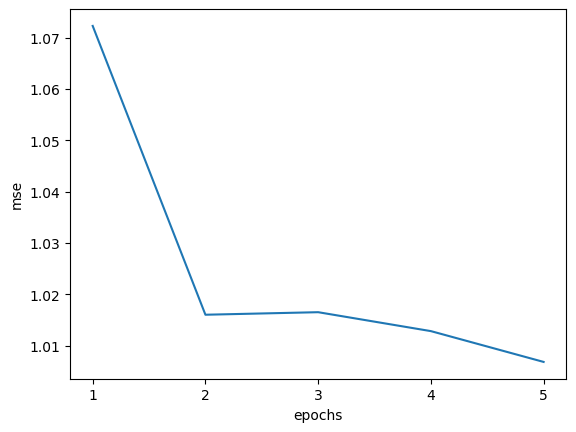

In [31]:
import matplotlib.pyplot as plt

loss_mse = history.history['loss']
plt.xticks(range(1, len(loss_mse)+1))
plt.ylabel('mse')
plt.xlabel('epochs')
plt.plot(range(1, len(loss_mse)+1), loss_mse)